# Gaussian $\mu$ and Sampled Points

Visualization for: **Approximation of a target distribution $\mu$ with a finite set of points $\{x_i\}_{i=1}^n$.**

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil

# Reproducibility
rng = np.random.default_rng(7)

# Prefer full LaTeX text rendering when available.
if shutil.which("latex") is not None:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
    })
else:
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "mathtext.fontset": "cm",
    })

In [10]:
# 2D Gaussian target distribution mu = N(mean, cov)
mean = np.array([0.0, 0.0])
cov = np.array([[1.0, 0.6], [0.6, 1.5]])
n_samples = 120
samples = rng.multivariate_normal(mean, cov, size=n_samples)

In [11]:
# Grid and exact Gaussian density (no scipy dependency)
x = np.linspace(-4, 4, 220)
y = np.linspace(-4, 4, 220)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

inv_cov = np.linalg.inv(cov)
det_cov = np.linalg.det(cov)
norm_const = 1.0 / (2.0 * np.pi * np.sqrt(det_cov))
diff = pos - mean
quad = np.einsum('...i,ij,...j->...', diff, inv_cov, diff)
Z = norm_const * np.exp(-0.5 * quad)

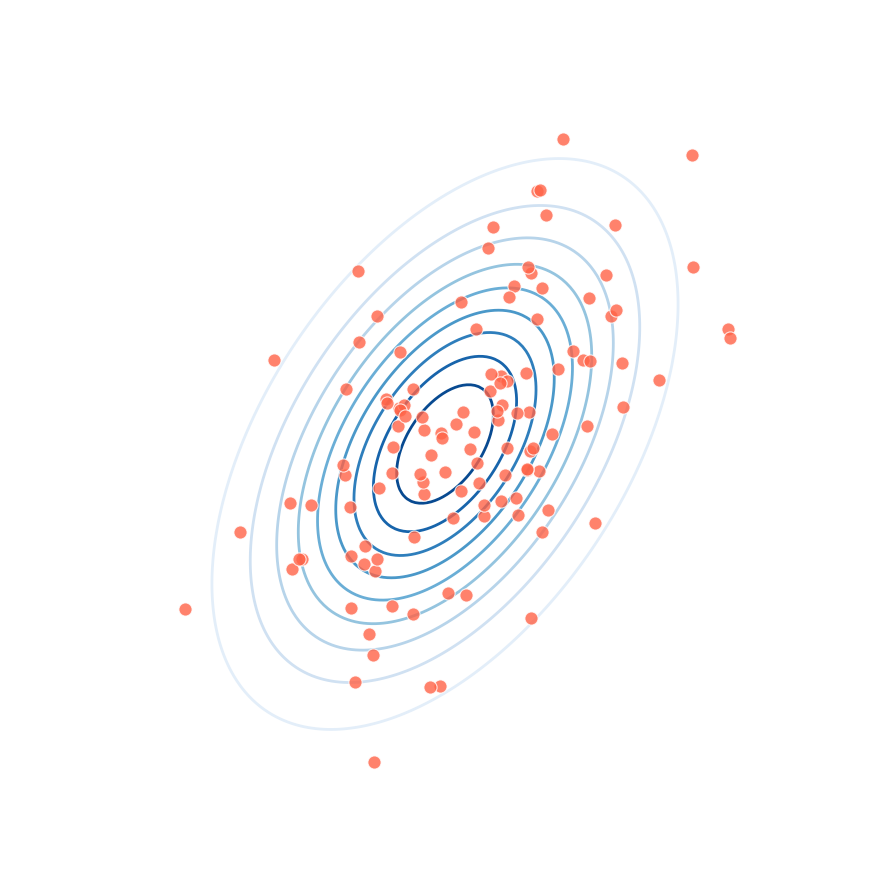

In [ ]:
fig, ax = plt.subplots(figsize=(7.2, 7.2))

ax.contour(X, Y, Z, levels=10, cmap='Blues', linewidths=2.0)

ax.scatter(
    samples[:, 0],
    samples[:, 1],
    s=90,
    c='tomato',
    alpha=0.8,
    edgecolor='white',
    linewidth=0.8,
    zorder=3,
 )

ax.set_title(r'Target distribution $\\mu$ and finite samples', fontsize=30, pad=8)

# Much tighter window around the high-density Gaussian region.
std_x = np.sqrt(cov[0, 0])
std_y = np.sqrt(cov[1, 1])
k = 1.85
ax.set_xlim(mean[0] - k * std_x, mean[0] + k * std_x)
ax.set_ylim(mean[1] - k * std_y, mean[1] + k * std_y)

# Remove labels, ticks, tick labels, and legend for a clean slide figure.
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_aspect('equal', adjustable='box')
ax.margins(0)
ax.grid(False)
fig.subplots_adjust(left=0.00, right=1.00, bottom=0.00, top=0.93)

output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "gaussian_mu_samples.pdf", bbox_inches='tight', pad_inches=0.0)
plt.close(fig)